In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [2]:
df = pd.read_csv("thyroid_dataset.csv")
df.head 

<bound method NDFrame.head of        Age  Sex  on_thyroxine  query_on_thyroxine  on_antithyroid_medication  \
0     0.45    1             0                   0                          0   
1     0.61    0             0                   0                          0   
2     0.16    0             1                   0                          0   
3     0.85    0             0                   0                          0   
4     0.75    1             0                   0                          0   
...    ...  ...           ...                 ...                        ...   
6911  0.65    0             1                   0                          0   
6912  0.77    0             0                   0                          0   
6913  0.41    0             0                   0                          0   
6914  0.64    1             0                   0                          0   
6915  0.46    0             0                   0                          0   

      sic

In [3]:
X = df.drop('Outlier_label', axis=1)
y = df['Outlier_label']

In [4]:
X.head

<bound method NDFrame.head of        Age  Sex  on_thyroxine  query_on_thyroxine  on_antithyroid_medication  \
0     0.45    1             0                   0                          0   
1     0.61    0             0                   0                          0   
2     0.16    0             1                   0                          0   
3     0.85    0             0                   0                          0   
4     0.75    1             0                   0                          0   
...    ...  ...           ...                 ...                        ...   
6911  0.65    0             1                   0                          0   
6912  0.77    0             0                   0                          0   
6913  0.41    0             0                   0                          0   
6914  0.64    1             0                   0                          0   
6915  0.46    0             0                   0                          0   

      sic

In [5]:
scaler = StandardScaler()
scaler.fit_transform(X)

array([[-2.34449113e-02,  1.50050924e+00, -3.94405319e-01, ...,
        -1.40951598e+00, -3.74590514e-02, -1.25859776e+00],
       [ 2.40791602e-03, -6.66440415e-01, -3.94405319e-01, ...,
        -6.57814578e-01,  2.27969782e-01, -5.68029663e-01],
       [-7.03031607e-02, -6.66440415e-01,  2.53546276e+00, ...,
        -7.17159426e-01,  4.34414431e-01, -7.13412420e-01],
       ...,
       [-2.99081181e-02, -6.66440415e-01, -3.94405319e-01, ...,
         6.08208844e-01,  7.58827450e-01,  2.49748343e-01],
       [ 7.25532113e-03,  1.50050924e+00, -3.94405319e-01, ...,
         2.32358141e-01, -7.96695877e-03,  4.67822478e-01],
       [-2.18291096e-02, -6.66440415e-01, -3.94405319e-01, ...,
        -2.48028670e-02,  8.05093192e-02,  1.22538431e-01]],
      shape=(6916, 21))

In [6]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(n_estimators=200, contamination='auto', random_state=42)
clf = model.fit(X)

In [7]:
labels = clf.predict(X)

In [8]:
labels

array([ 1,  1, -1, ...,  1,  1,  1], shape=(6916,))

In [9]:
#visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


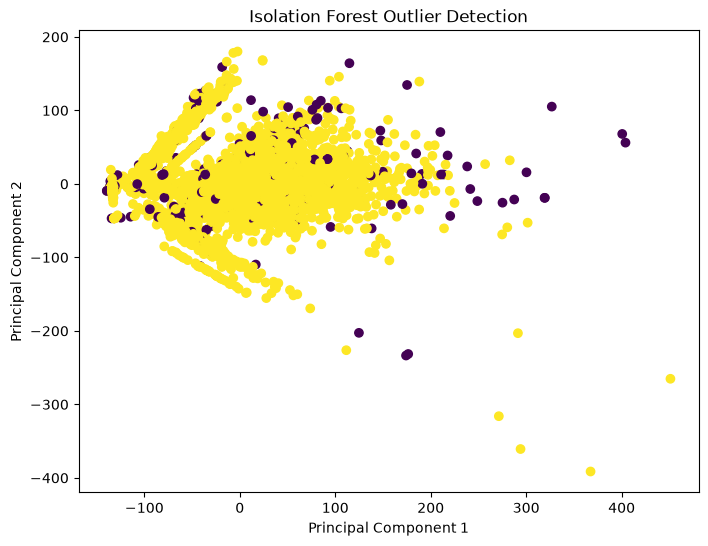

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title('Isolation Forest Outlier Detection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()


In [11]:
import numpy as np
n_outliers = np.sum(labels == -1)
n_normal = np.sum(labels == 1)

print("outlier=", n_outliers)
print("normal=", n_normal)


outlier= 270
normal= 6646


##LOF

In [13]:
from sklearn.neighbors import LocalOutlierFactor


In [14]:
neighbor_model = LocalOutlierFactor()
labels_lof = neighbor_model.fit_predict(X)

Text(0.5, 1.0, 'Local Outlier Factor (LOF) Outlier Detection')

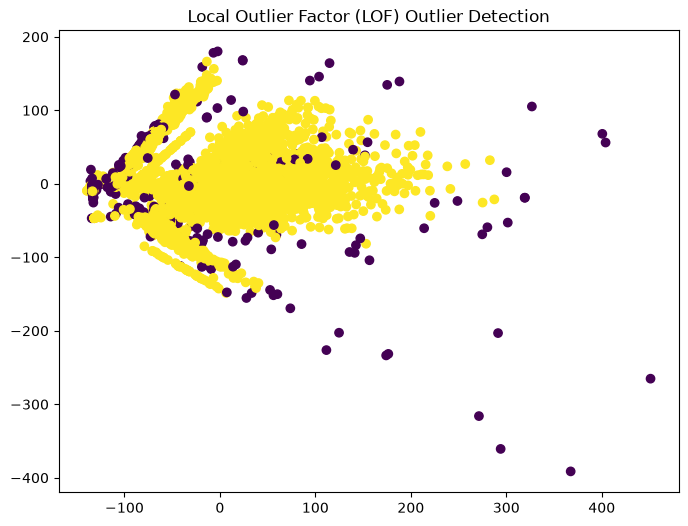

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_lof)
plt.title('Local Outlier Factor (LOF) Outlier Detection')


In [16]:
n_outliers_lof = np.sum(labels_lof == -1)
n_normal_lof = np.sum(labels_lof == 1)
print("LOF outlier=", n_outliers_lof)
print("LOF normal=", n_normal_lof)

LOF outlier= 431
LOF normal= 6485
